# Customer Churn Intelligence System

Notebook ini membangun satu sistem ML terintegrasi:

1. EDA dan data understanding
2. Model churn prediction berbasis data tabular
3. Model sentiment analysis berbasis feedback text
4. Model gabungan tabular + sentiment
5. Business logic untuk risk tier dan rekomendasi tindakan
6. Penyimpanan artefak model agar siap dipakai lagi


In [1]:
%pip install -q pandas numpy matplotlib seaborn scikit-learn joblib


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import warnings
warnings.filterwarnings('ignore')

import os
import re
import json
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

RAW_DATA_PATH = 'dataset/telco_churn_with_all_feedback.csv'
PREP_DATA_PATH = 'dataset/telco_prep.csv'
OUTPUT_DIR = 'dataset/output'
RANDOM_STATE = 42
TEST_SIZE = 0.2

os.makedirs(OUTPUT_DIR, exist_ok=True)
print('Setup selesai.')


Setup selesai.


In [3]:
# 1) Load dan cleaning data utama
df = pd.read_csv(RAW_DATA_PATH)
print('Shape awal:', df.shape)

df = df.copy()
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['CustomerFeedback'] = df['CustomerFeedback'].fillna('')
df['ChurnLabel'] = (df['Churn'].astype(str).str.strip().str.lower() == 'yes').astype(int)

drop_cols = [c for c in ['customerID', 'PromptInput'] if c in df.columns]
df = df.drop(columns=drop_cols)

print('Shape setelah cleaning:', df.shape)
print('\nMissing value terbanyak:')
display(df.isna().sum().sort_values(ascending=False).head(10).to_frame('missing_count'))
display(df.head(3))


Shape awal: (7043, 23)
Shape setelah cleaning: (7043, 22)

Missing value terbanyak:


,missing_count
TotalCharges,11
gender,0
Partner,0
Dependents,0
tenure,0
SeniorCitizen,0
PhoneService,0
MultipleLines,0
OnlineSecurity,0
InternetService,0


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,CustomerFeedback,ChurnLabel
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,I have been using the DSL internet service fro...,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No,I have been a customer with this company for o...,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,I recently signed up for DSL internet service ...,1


Churn rate keseluruhan: 26.54%


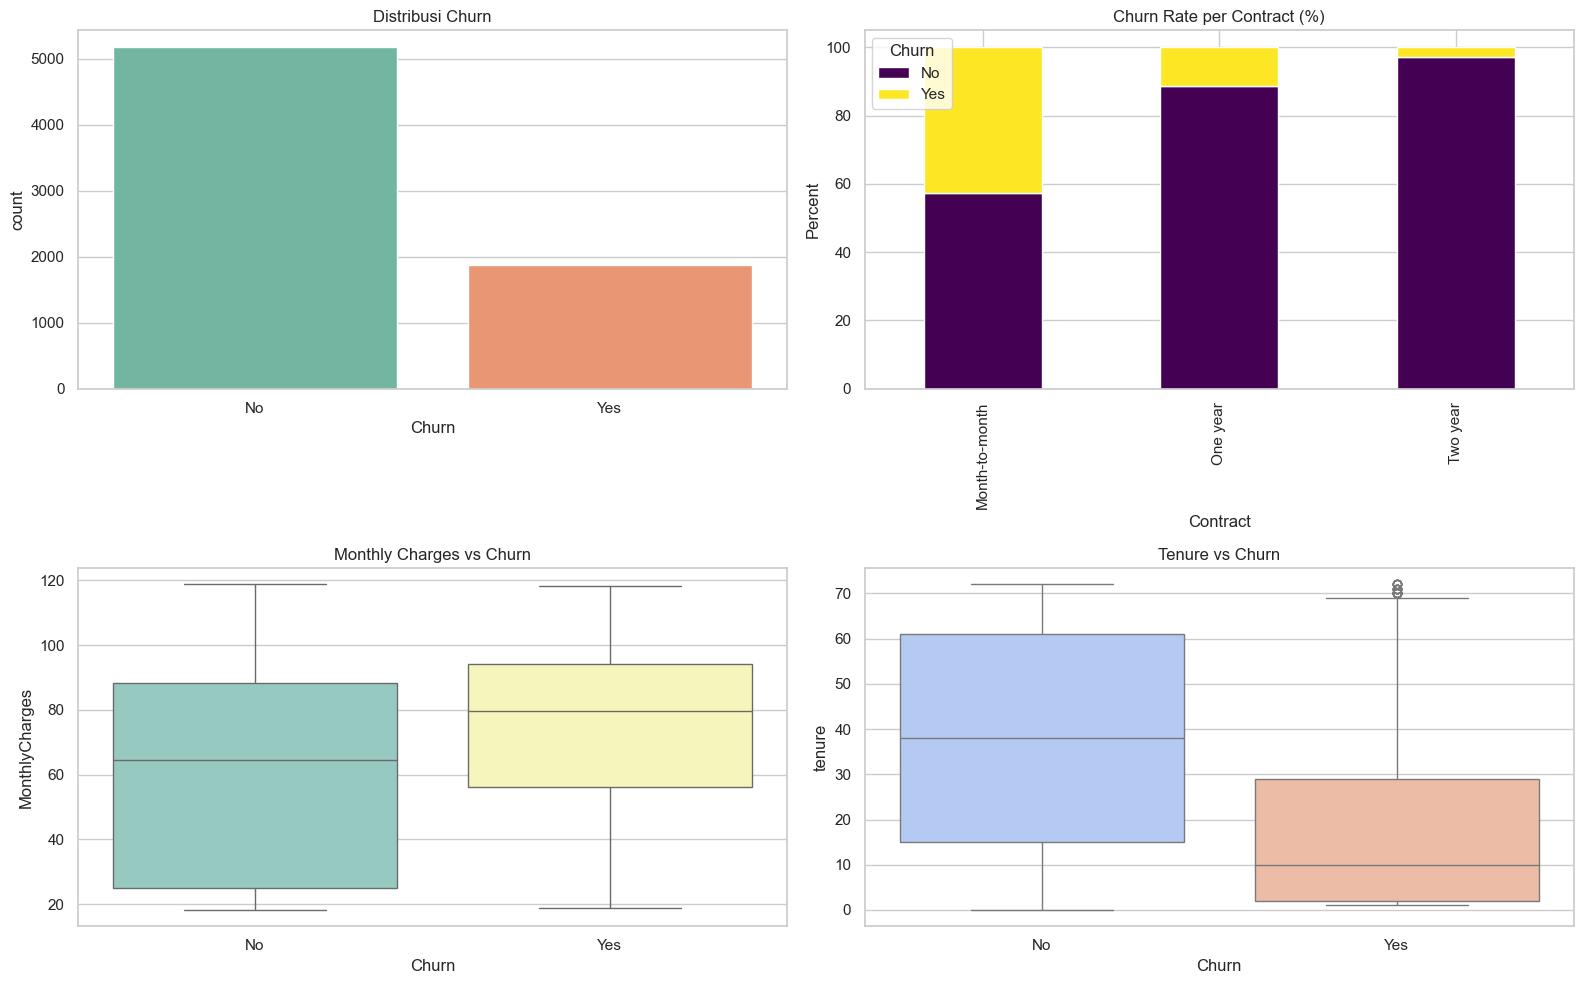

,metric,value
0,rows,7043.00
1,columns,22.00
2,churn_rate_pct,26.54
3,avg_monthly_charge,64.76
4,avg_tenure,32.37


In [4]:
# 2) EDA singkat
print('Churn rate keseluruhan: {:.2f}%'.format(df['ChurnLabel'].mean() * 100))

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

sns.countplot(data=df, x='Churn', ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('Distribusi Churn')

contract_rate = pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100
contract_rate.plot(kind='bar', stacked=True, ax=axes[0, 1], colormap='viridis')
axes[0, 1].set_title('Churn Rate per Contract (%)')
axes[0, 1].set_ylabel('Percent')

sns.boxplot(data=df, x='Churn', y='MonthlyCharges', ax=axes[1, 0], palette='Set3')
axes[1, 0].set_title('Monthly Charges vs Churn')

sns.boxplot(data=df, x='Churn', y='tenure', ax=axes[1, 1], palette='coolwarm')
axes[1, 1].set_title('Tenure vs Churn')

plt.tight_layout()
plt.show()

eda_summary = pd.DataFrame({
    'metric': ['rows', 'columns', 'churn_rate_pct', 'avg_monthly_charge', 'avg_tenure'],
    'value': [len(df), df.shape[1], round(df['ChurnLabel'].mean() * 100, 2), round(df['MonthlyCharges'].mean(), 2), round(df['tenure'].mean(), 2)]
})
display(eda_summary)


## Model 1: Churn Prediction dari Data Tabular

Kita mulai dari baseline yang bersih: hanya fitur numerik dan kategorikal, tanpa teks mentah `CustomerFeedback`.


In [5]:
# 3) Persiapan fitur tabular
tabular_feature_cols = [c for c in df.columns if c not in ['Churn', 'ChurnLabel', 'CustomerFeedback']]
X_tab = df[tabular_feature_cols].copy()
y = df['ChurnLabel'].copy()

num_cols_tab = X_tab.select_dtypes(include=['number']).columns.tolist()
cat_cols_tab = X_tab.select_dtypes(exclude=['number']).columns.tolist()
for col in cat_cols_tab:
    X_tab[col] = X_tab[col].astype(str)

X_tab_train, X_tab_test, y_train, y_test = train_test_split(
    X_tab, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

tabular_preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), num_cols_tab),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), cat_cols_tab)
    ]
)

tabular_models = {
    'LogisticRegression': LogisticRegression(max_iter=3000, class_weight='balanced', random_state=RANDOM_STATE),
    'RandomForest': RandomForestClassifier(n_estimators=300, max_depth=12, min_samples_leaf=2, class_weight='balanced_subsample', random_state=RANDOM_STATE, n_jobs=-1)
}

tabular_results = []
tabular_fitted = {}

for name, model in tabular_models.items():
    pipeline = Pipeline([
        ('preprocess', tabular_preprocessor),
        ('model', clone(model))
    ])
    pipeline.fit(X_tab_train, y_train)
    y_prob = pipeline.predict_proba(X_tab_test)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)

    metrics_row = {
        'model': name,
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_prob)
    }
    tabular_results.append(metrics_row)
    tabular_fitted[name] = {'pipeline': pipeline, 'y_prob': y_prob, 'y_pred': y_pred}

tabular_results_df = pd.DataFrame(tabular_results).sort_values('roc_auc', ascending=False)
display(tabular_results_df)


,model,precision,recall,f1,roc_auc
0,LogisticRegression,0.514334,0.815508,0.630817,0.847813
1,RandomForest,0.569536,0.689840,0.623942,0.846963


## Model 2: Sentiment Analysis dari Feedback Text

Dataset mentah tidak punya label sentiment kategorikal, jadi kita manfaatkan `dataset/telco_prep.csv` yang sudah berisi skor `sentiment`. Skor itu kita ubah menjadi 3 kelas:

- `Positive` jika skor > 0.05
- `Negative` jika skor < -0.05
- `Neutral` untuk sisanya


In [6]:
# 4) Persiapan dataset sentiment
prep_df = pd.read_csv(PREP_DATA_PATH)
prep_df = prep_df.copy()

unnamed_cols = [c for c in prep_df.columns if c.lower().startswith('unnamed') or c == '']
if unnamed_cols:
    prep_df = prep_df.drop(columns=unnamed_cols)

prep_df['CustomerFeedback'] = prep_df['CustomerFeedback'].fillna('')
prep_df['sentiment'] = pd.to_numeric(prep_df['sentiment'], errors='coerce').fillna(0.0)

def sentiment_bucket(score):
    if score > 0.05:
        return 'Positive'
    if score < -0.05:
        return 'Negative'
    return 'Neutral'

prep_df['sentiment_label'] = prep_df['sentiment'].apply(sentiment_bucket)
prep_df = prep_df[prep_df['CustomerFeedback'].str.strip() != ''].copy()

print('Shape sentiment dataset:', prep_df.shape)
display(prep_df['sentiment_label'].value_counts().to_frame('count'))

X_text = prep_df['CustomerFeedback']
y_text = prep_df['sentiment_label']

X_text_train, X_text_test, y_text_train, y_text_test = train_test_split(
    X_text, y_text, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_text
)

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

sentiment_model = Pipeline([
    ('tfidf', TfidfVectorizer(preprocessor=clean_text, stop_words='english', ngram_range=(1, 2), min_df=3, max_features=5000)),
    ('clf', LogisticRegression(max_iter=3000, class_weight='balanced', random_state=RANDOM_STATE))
])

sentiment_model.fit(X_text_train, y_text_train)
text_pred = sentiment_model.predict(X_text_test)

print('Classification report sentiment model:')
print(classification_report(y_text_test, text_pred))

df['predicted_sentiment_label'] = sentiment_model.predict(df['CustomerFeedback'])
sentiment_proba = pd.DataFrame(
    sentiment_model.predict_proba(df['CustomerFeedback']),
    columns=[f"sent_prob_{cls.lower()}" for cls in sentiment_model.named_steps['clf'].classes_]
)
df = pd.concat([df.reset_index(drop=True), sentiment_proba.reset_index(drop=True)], axis=1)

score_map = {'Negative': -1, 'Neutral': 0, 'Positive': 1}
df['predicted_sentiment_score'] = df['predicted_sentiment_label'].map(score_map)
df['feedback_length'] = df['CustomerFeedback'].str.len()
df['feedback_word_count'] = df['CustomerFeedback'].str.split().str.len()

display(df[['CustomerFeedback', 'predicted_sentiment_label', 'predicted_sentiment_score']].head(5))


Shape sentiment dataset: (7032, 26)


,count
sentiment_label,
Positive,5999
Neutral,652
Negative,381


Classification report sentiment model:
              precision    recall  f1-score   support

    Negative       0.68      0.78      0.72        76
     Neutral       0.42      0.66      0.51       131
    Positive       0.98      0.91      0.94      1200

    accuracy                           0.88      1407
   macro avg       0.69      0.78      0.73      1407
weighted avg       0.91      0.88      0.89      1407



,CustomerFeedback,predicted_sentiment_label,predicted_sentiment_score
0,I have been using the DSL internet service fro...,Positive,1
1,I have been a customer with this company for o...,Positive,1
2,I recently signed up for DSL internet service ...,Negative,-1
3,I have been a loyal customer with this company...,Positive,1
4,I recently switched to this fiber optic intern...,Neutral,0


## Model 3: Combined Model

Di tahap ini kita gabungkan fitur tabular dengan sinyal NLP hasil model sentiment. Ini yang membuat sistem lebih dekat ke kebutuhan bisnis nyata.


,model,precision,recall,f1,roc_auc
1,Combined Tabular + Sentiment,0.879581,0.898396,0.888889,0.978486
0,Best Tabular,0.514334,0.815508,0.630817,0.847813


Classification report combined model:
              precision    recall  f1-score   support

           0      0.963     0.956     0.959      1035
           1      0.880     0.898     0.889       374

    accuracy                          0.940      1409
   macro avg      0.921     0.927     0.924      1409
weighted avg      0.941     0.940     0.941      1409



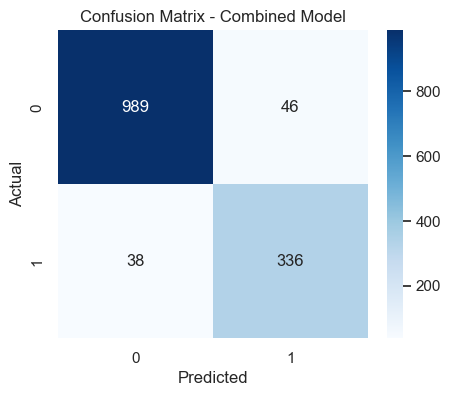

In [7]:
# 5) Combined model: tabular + sentiment features
combined_feature_cols = [
    c for c in df.columns
    if c not in ['Churn', 'ChurnLabel', 'CustomerFeedback']
]

X_combined = df[combined_feature_cols].copy()
num_cols_combined = X_combined.select_dtypes(include=['number']).columns.tolist()
cat_cols_combined = X_combined.select_dtypes(exclude=['number']).columns.tolist()
for col in cat_cols_combined:
    X_combined[col] = X_combined[col].astype(str)

X_comb_train, X_comb_test, y_comb_train, y_comb_test = train_test_split(
    X_combined, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

combined_preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), num_cols_combined),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), cat_cols_combined)
    ]
)

combined_model = Pipeline([
    ('preprocess', combined_preprocessor),
    ('model', RandomForestClassifier(n_estimators=400, max_depth=14, min_samples_leaf=2, class_weight='balanced_subsample', random_state=RANDOM_STATE, n_jobs=-1))
])

combined_model.fit(X_comb_train, y_comb_train)
combined_prob = combined_model.predict_proba(X_comb_test)[:, 1]
combined_pred = (combined_prob >= 0.5).astype(int)

combined_metrics = pd.DataFrame([
    {
        'model': 'Best Tabular',
        'precision': precision_score(y_test, tabular_fitted[tabular_results_df.iloc[0]['model']]['y_pred']),
        'recall': recall_score(y_test, tabular_fitted[tabular_results_df.iloc[0]['model']]['y_pred']),
        'f1': f1_score(y_test, tabular_fitted[tabular_results_df.iloc[0]['model']]['y_pred']),
        'roc_auc': roc_auc_score(y_test, tabular_fitted[tabular_results_df.iloc[0]['model']]['y_prob'])
    },
    {
        'model': 'Combined Tabular + Sentiment',
        'precision': precision_score(y_comb_test, combined_pred),
        'recall': recall_score(y_comb_test, combined_pred),
        'f1': f1_score(y_comb_test, combined_pred),
        'roc_auc': roc_auc_score(y_comb_test, combined_prob)
    }
]).sort_values('roc_auc', ascending=False)

display(combined_metrics)
print('Classification report combined model:')
print(classification_report(y_comb_test, combined_pred, digits=3))

cm = confusion_matrix(y_comb_test, combined_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Combined Model')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


In [8]:
# 6) Scoring semua customer + business logic layer
df['churn_probability'] = combined_model.predict_proba(X_combined)[:, 1]
df['churn_prediction'] = np.where(df['churn_probability'] >= 0.5, 'Yes', 'No')

def risk_tier(prob):
    if prob >= 0.80:
        return 'High'
    if prob >= 0.50:
        return 'Medium'
    return 'Low'

def build_recommendation(row):
    if row['churn_probability'] >= 0.80:
        if row['predicted_sentiment_label'] == 'Negative':
            return 'High risk -> retention call prioritas, service recovery, dan diskon personal 15-20%'
        return 'High risk -> retention call dan tawarkan upgrade kontrak'
    if row['churn_probability'] >= 0.50:
        if str(row.get('Contract', '')).lower() == 'month-to-month':
            return 'Medium risk -> dorong migrasi ke kontrak 1 tahun + promo bundle'
        return 'Medium risk -> kirim promo personal dan follow-up CRM'
    return 'Low risk -> pertahankan engagement lewat loyalty campaign'

def build_reason(row):
    reasons = []
    if row.get('tenure', 999) <= 12:
        reasons.append('tenure pendek')
    if row.get('MonthlyCharges', 0) >= 70:
        reasons.append('monthly charge tinggi')
    if str(row.get('Contract', '')).lower() == 'month-to-month':
        reasons.append('kontrak bulanan')
    if row.get('predicted_sentiment_label') == 'Negative':
        reasons.append('feedback negatif')
    if 'electronic check' in str(row.get('PaymentMethod', '')).lower():
        reasons.append('metode pembayaran electronic check')
    return ', '.join(reasons) if reasons else 'tidak ada sinyal risiko dominan'

df['risk_tier'] = df['churn_probability'].apply(risk_tier)
df['risk_reason'] = df.apply(build_reason, axis=1)
df['recommendation'] = df.apply(build_recommendation, axis=1)

priority_cols = [
    'gender', 'SeniorCitizen', 'tenure', 'Contract', 'PaymentMethod', 'MonthlyCharges',
    'predicted_sentiment_label', 'predicted_sentiment_score', 'churn_probability',
    'risk_tier', 'risk_reason', 'recommendation'
]
priority_cols = [c for c in priority_cols if c in df.columns]

display(df.sort_values('churn_probability', ascending=False)[priority_cols].head(15))
display(df['risk_tier'].value_counts(normalize=True).round(3).to_frame('proportion'))


,gender,SeniorCitizen,tenure,Contract,PaymentMethod,MonthlyCharges,predicted_sentiment_label,predicted_sentiment_score,churn_probability,risk_tier,risk_reason,recommendation
3220,Female,0,2,Month-to-month,Electronic check,34.70,Negative,-1,1.0,High,"tenure pendek, kontrak bulanan, feedback negat...","High risk -> retention call prioritas, service..."
3971,Male,0,1,Month-to-month,Electronic check,50.45,Negative,-1,1.0,High,"tenure pendek, kontrak bulanan, feedback negat...","High risk -> retention call prioritas, service..."
6605,Female,0,1,Month-to-month,Electronic check,70.50,Neutral,0,1.0,High,"tenure pendek, monthly charge tinggi, kontrak ...",High risk -> retention call dan tawarkan upgra...
4394,Female,0,2,Month-to-month,Electronic check,35.10,Negative,-1,1.0,High,"tenure pendek, kontrak bulanan, feedback negat...","High risk -> retention call prioritas, service..."
2504,Male,0,3,Month-to-month,Electronic check,79.25,Neutral,0,1.0,High,"tenure pendek, monthly charge tinggi, kontrak ...",High risk -> retention call dan tawarkan upgra...
3352,Male,0,1,Month-to-month,Electronic check,69.55,Neutral,0,1.0,High,"tenure pendek, kontrak bulanan, metode pembaya...",High risk -> retention call dan tawarkan upgra...
2488,Female,0,1,Month-to-month,Electronic check,69.50,Neutral,0,1.0,High,"tenure pendek, kontrak bulanan, metode pembaya...",High risk -> retention call dan tawarkan upgra...
489,Male,0,1,Month-to-month,Electronic check,74.35,Neutral,0,1.0,High,"tenure pendek, monthly charge tinggi, kontrak ...",High risk -> retention call dan tawarkan upgra...
4404,Female,0,1,Month-to-month,Mailed check,45.95,Negative,-1,1.0,High,"tenure pendek, kontrak bulanan, feedback negatif","High risk -> retention call prioritas, service..."
2064,Male,0,1,Month-to-month,Mailed check,45.30,Negative,-1,1.0,High,"tenure pendek, kontrak bulanan, feedback negatif","High risk -> retention call prioritas, service..."


,proportion
risk_tier,
Low,0.728
High,0.215
Medium,0.057


In [9]:
# 7) Simpan artefak model dan output
best_tabular_name = tabular_results_df.iloc[0]['model']
best_tabular_pipeline = tabular_fitted[best_tabular_name]['pipeline']

joblib.dump(best_tabular_pipeline, os.path.join(OUTPUT_DIR, 'tabular_churn_model.pkl'))
joblib.dump(sentiment_model, os.path.join(OUTPUT_DIR, 'sentiment_text_model.pkl'))
joblib.dump(combined_model, os.path.join(OUTPUT_DIR, 'combined_churn_model.pkl'))

output_cols = [
    c for c in [
        'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'InternetService',
        'Contract', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn',
        'predicted_sentiment_label', 'predicted_sentiment_score',
        'churn_probability', 'churn_prediction', 'risk_tier', 'risk_reason', 'recommendation'
    ] if c in df.columns
]
df[output_cols].to_csv(os.path.join(OUTPUT_DIR, 'customer_churn_intelligence_output.csv'), index=False)

metadata = {
    'raw_data_path': RAW_DATA_PATH,
    'prep_data_path': PREP_DATA_PATH,
    'best_tabular_model': best_tabular_name,
    'tabular_metrics': tabular_results_df.to_dict(orient='records'),
    'combined_metrics': combined_metrics.to_dict(orient='records'),
    'risk_thresholds': {'high': 0.8, 'medium': 0.5},
    'api_example': {
        'request': {
            'tenure': 5,
            'monthly_charges': 80,
            'feedback': 'layanan mahal dan lambat'
        },
        'response_fields': ['churn_probability', 'predicted_sentiment_label', 'recommendation']
    }
}

with open(os.path.join(OUTPUT_DIR, 'model_metadata.json'), 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=2)

print('Artefak tersimpan di:', OUTPUT_DIR)


Artefak tersimpan di: dataset/output


## Ringkasan

Notebook `2.ipynb` sekarang sudah mencakup alur yang kamu butuhkan:

- EDA dan pemahaman pola churn
- Baseline churn model berbasis tabular
- Sentiment model berbasis TF-IDF + Logistic Regression
- Combined churn model dengan fitur tabular + sentiment
- Risk tier dan recommendation layer
- Export model `.pkl` dan hasil scoring `.csv`

Kalau mau lanjut ke tahap deployment, model gabungan ini sudah paling siap dijadikan endpoint `POST /predict`.
